# Training

Agregamos la carpeta padre al Path para poder importar el módulo `cowaver`:

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

## Funciones de graficado

In [2]:
import io
import torch
import torchaudio
import ipywidgets as widgets
import cowaver
from cowaver.utils import AUDIO_SAMPLE_RATE

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

In [3]:
from pathlib import Path
from cowaver.utils import encontrar_dispositivo

DEVICE = encontrar_dispositivo()
DATASET_SIZE = 480

# Idioma, puede ser "french" o "spanish"
LANGUAGE = "spanish"

# Rutas a los datos
workspace_path = Path("../") / LANGUAGE
compressed_phones_path = workspace_path / f"kalulu-phones-{DATASET_SIZE}.tar.xz"
compressed_spoken_path = workspace_path / f"kalulu-spoken-{DATASET_SIZE}.tar.xz"

print(f"Buscando {compressed_phones_path}", end="... ")
print("OK" if compressed_phones_path.exists() else "ERROR")

print(f"Buscando {compressed_spoken_path}", end="... ")
print("OK" if compressed_spoken_path.exists() else "ERROR")

# Carpeta donde se descomprimirán los datos
data_path = workspace_path / "data"

# Carpeta donde se guardan los checkpoints
checkpoints_path = workspace_path / "checkpoints" / str(DATASET_SIZE)

Buscando dispositivo... CPU
Buscando ..\spanish\kalulu-phones-480.tar.xz... OK
Buscando ..\spanish\kalulu-spoken-480.tar.xz... OK


In [4]:
from cowaver.utils import descomprimir_archivo, listar_clases, separar_clases
from cowaver.datamodules import TinyPairedMel

phones_path = descomprimir_archivo(compressed_phones_path, data_path)
spoken_path = descomprimir_archivo(compressed_spoken_path, data_path)

palabras = listar_clases(phones_path / "train")

print("Total de palabras:", len(palabras))

palabras_a_entrenar, palabras_a_generalizar = separar_clases(palabras, fraction=0.2)
print("Palabras a entrenar:", len(palabras_a_entrenar))
print(f"Palabras a generalizar ({len(palabras_a_generalizar)}):", palabras_a_generalizar)

full_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
training_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
generalization_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_generalizar)

Descomprimiendo ..\spanish\kalulu-phones-480.tar.xz en ..\spanish\data\kalulu-phones-480... YA EXISTE
Descomprimiendo ..\spanish\kalulu-spoken-480.tar.xz en ..\spanish\data\kalulu-spoken-480... YA EXISTE
Total de palabras: 480
Palabras a entrenar: 384
Palabras a generalizar (96): ['abierto', 'adulto', 'aire', 'alta', 'alumno', 'ama', 'ancho', 'artista', 'atleta', 'azúcar', 'bandera', 'calle', 'calor', 'cero', 'cerro', 'cohete', 'con', 'copa', 'cruzar', 'culpa', 'dado', 'dama', 'dejar', 'doce', 'enseña', 'era', 'esquina', 'fama', 'faro', 'feliz', 'fino', 'fruta', 'gracias', 'grande', 'helado', 'himno', 'idea', 'jugar', 'lava', 'lengua', 'limpio', 'los', 'luchar', 'magia', 'mancha', 'manga', 'marzo', 'medida', 'mes', 'miedo', 'modelo', 'moneda', 'montaña', 'mágico', 'música', 'niños', 'novios', 'nube', 'nudo', 'nueve', 'nuevo', 'octubre', 'oficina', 'ojo', 'parque', 'paseo', 'persona', 'pie', 'piel', 'pino', 'pintor', 'pintura', 'plana', 'planta', 'pluma', 'ratones', 'raíz', 'reino', 'ro

In [5]:
import matplotlib.pyplot as plt
from cowaver.datamodules import TinyPairedMel
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 4), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        plt.show()

    display(widgets.VBox([out, widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform)])]))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Speech Autoencoder

In [6]:
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

import cowaver
from cowaver.modules.autoencoders import ConvAutoEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableMixin
from cowaver.utils import distancia_mel, topk
    
class SpeechAutoEncoder(TrainableMixin, ConvAutoEncoder):
    def __init__(self, seq_len: int = 49, mel_bins: int = 80):
        super().__init__(x_dim=(1, seq_len, mel_bins), h_dim=256, n_filters=32, filter_size=5)
        self.seq_len = seq_len
        self.mel_bins = mel_bins

    @property
    def name(self) -> str:
        return f"autoencoder_sl{self.seq_len}_mb{self.mel_bins}"

    def training_step(self, batch, batch_idx, phase: int):
        (image, phonetized_mel, spoken_mel), target = batch
        B = image.size(0)
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(spoken_mel)
        return nn.functional.mse_loss(y_hat.reshape(B, -1), target=spoken_mel.reshape(B, -1))

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (image, phonetized_mel, spoken_mel), target = batch
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(spoken_mel)
        y_hat = y_hat.squeeze(1).transpose(1, 2)
        prototypes = data.mel_prototypes(y_hat.device)
        distances = distancia_mel(y_hat, prototypes)
        return topk(distances, target)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        return LinearLR(optimizer, start_factor=1.0, end_factor=programme.end_factor, total_iters=programme.decay_epochs())

In [7]:
from cowaver.models import TrainProgramme
from cowaver.utils import entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    num_phases=1,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4
)

# Uncomment to train
#
# speech_autoencoder = SpeechAutoEncoder()
# train_history = entrenar_red(net=speech_autoencoder, data=full_data, programme=programme, phase=1, dispositivo=DEVICE)
# guardar_checkpoint(speech_autoencoder, train_history=train_history, programme=programme, folder=checkpoints_path / "spoken")

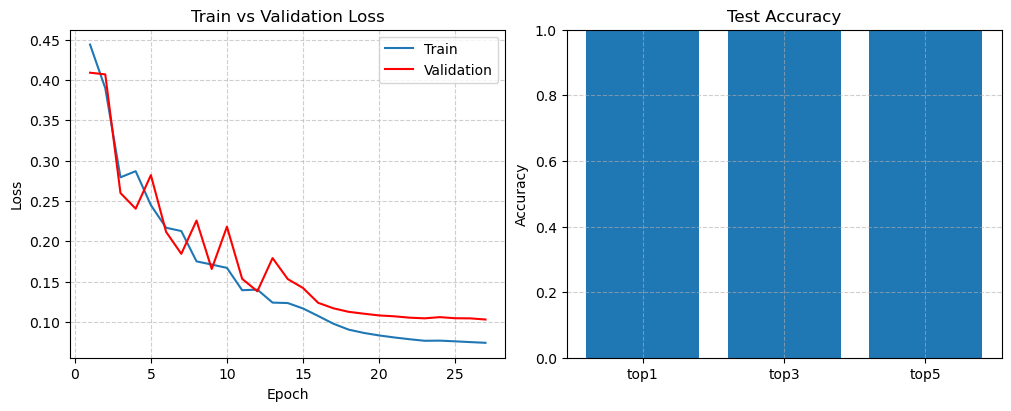

In [8]:
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

speech_autoencoder = SpeechAutoEncoder()
train_history = cargar_checkpoint(speech_autoencoder, folder=checkpoints_path / "spoken", silent=True)
train_history.train_losses = train_history.train_losses[1:]
train_history.val_losses = train_history.val_losses[1:]
test_results = evaluar_red(speech_autoencoder, full_data)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(test_results, ax=axes[1])
plt.show()

In [9]:
import matplotlib.pyplot as plt
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

speech_autoencoder = SpeechAutoEncoder()
cargar_checkpoint(speech_autoencoder, folder=checkpoints_path / "spoken", silent=True)
speech_autoencoder.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, _, spoken_mel), target = exploration_set[idx]
    spoken_waveform = extraer_waveform(spoken_mel)

    with torch.no_grad():
        reconstructed_mel = speech_autoencoder(spoken_mel.unsqueeze(1).transpose(2, 3))
    reconstructed_mel = reconstructed_mel.squeeze(1).transpose(1, 2)
    reconstructed_waveform = extraer_waveform(reconstructed_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(spoken_waveform, ax=axes[0][0])
        graficar_mel(spoken_mel, ax=axes[0][1])
        graficar_waveform(reconstructed_waveform, ax=axes[1][0])
        graficar_mel(reconstructed_mel, ax=axes[1][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(spoken_waveform), audio_widget(reconstructed_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Red de conciencia fonológica

In [10]:
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

from cowaver.modules.autoencoders import ConvAutoEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableMixin
from cowaver.utils import distancia_mel, topk
    
class PhonologicalAwarenessNet(TrainableMixin, ConvAutoEncoder):
    def __init__(self, seq_len: int = 49, mel_bins: int = 80):
        super().__init__(x_dim=(1, seq_len, mel_bins), h_dim=256, n_filters=32, filter_size=5)
        self.seq_len = seq_len
        self.mel_bins = mel_bins

        # Freeze decoder
        for param in self.decoder.parameters():
            param.requires_grad = False

    @property
    def name(self) -> str:
        return f"autoencoder_sl{self.seq_len}_mb{self.mel_bins}"

    def training_step(self, batch, batch_idx, phase: int):
        (image, phonetized_mel, spoken_mel), target = batch
        B = image.size(0)
        phonetized_mel = phonetized_mel.transpose(2, 3)
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(phonetized_mel)
        return nn.functional.mse_loss(y_hat.reshape(B, -1), target=spoken_mel.reshape(B, -1))

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (image, phonetized_mel, spoken_mel), target = batch
        phonetized_mel = phonetized_mel.transpose(2, 3)
        spoken_mel = spoken_mel.transpose(2, 3)
        y_hat = self(phonetized_mel)
        y_hat = y_hat.squeeze(1).transpose(1, 2)
        prototypes = data.mel_prototypes(y_hat.device)
        distances = distancia_mel(y_hat, prototypes)
        return topk(distances, target)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        return LinearLR(optimizer, start_factor=1.0, end_factor=programme.end_factor, total_iters=programme.decay_epochs())

In [11]:
programme = TrainProgramme(
    theta_max=30,
    num_phases=1,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4
)

# Uncomment to train
#
# phonological_awareness_net = PhonologicalAwarenes()
# train_history = entrenar_red(net=phonological_awareness_net, data=training_data, programme=programme, phase=1, dispositivo=DEVICE)
# guardar_checkpoint(phonological_awareness_net, train_history=train_history, programme=programme, folder=checkpoints_path / "paired")

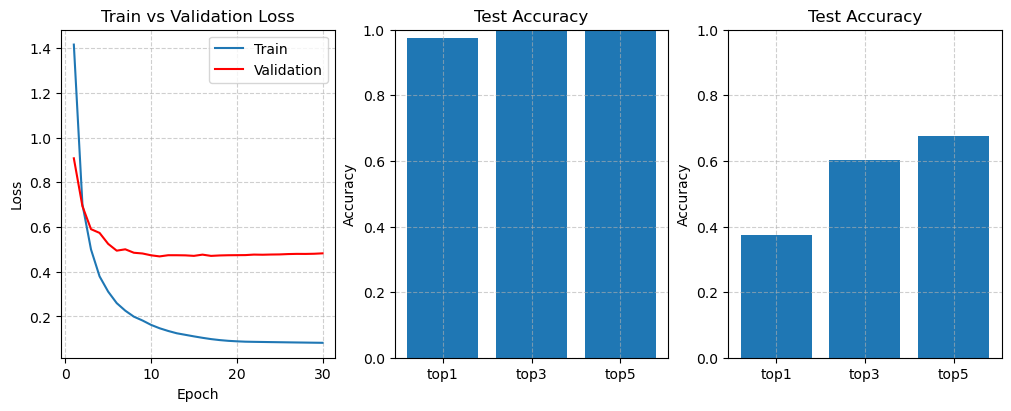

In [12]:
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

phonological_awareness_net = PhonologicalAwarenessNet()
train_history = cargar_checkpoint(phonological_awareness_net, folder=checkpoints_path / "paired", silent=True)
training_test_results = evaluar_red(phonological_awareness_net, training_data)
generalization_test_results = evaluar_red(phonological_awareness_net, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

In [13]:
import matplotlib.pyplot as plt
from cowaver.datamodules import TinyPairedMel
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_awareness_net = PhonologicalAwarenessNet()
cargar_checkpoint(phonological_awareness_net, folder=checkpoints_path / "paired", silent=True)
phonological_awareness_net.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    phonetized_mel = phonetized_mel.unsqueeze(1).transpose(2, 3)
    with torch.no_grad():
        h = phonological_awareness_net.encoder(phonetized_mel.to(DEVICE))
        mel_hat = phonological_awareness_net.decoder(h)
    predicted_mel = mel_hat.squeeze(1).transpose(1, 2)
    predicted_waveform = extraer_waveform(predicted_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(3, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        graficar_embedding(h, ax=axes[2][0], vmin=h.min(), vmax=h.max())
        graficar_mel(predicted_mel, ax=axes[2][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform), audio_widget(predicted_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Ruta fonológica de la lectura

In [14]:
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

from cowaver.modules.encoders import AvgPooledITEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableMixin
from cowaver.utils import distancia_mel, topk

class PhonologicalRouteNet(TrainableMixin, nn.Module):
    def __init__(self, h_dim=256, seq_len: int = 49, mel_bins: int = 80):
        super().__init__()
        self.h_dim = h_dim
        self.seq_len = seq_len
        self.mel_bins = mel_bins
        
        self.encoder = AvgPooledITEncoder()
        self.rnn = nn.RNN(
            input_size=512,
            hidden_size=256,
            nonlinearity='tanh',
            batch_first=True,
            bidirectional=False
        )
        self.proj = nn.Linear(256, h_dim)
        
        self.phonological_awareness = PhonologicalAwarenessNet(seq_len, mel_bins)
        for param in self.phonological_awareness.parameters():
            param.requires_grad = False

        self.register_buffer('h_mean', torch.zeros(h_dim))
        self.register_buffer('h_std', torch.ones(h_dim))

    @property
    def name(self) -> str:
        return f"visual_encoder_hd{self.h_dim}"

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        v = self.encoder(x)
        out, h_n = self.rnn(v)
        h_norm = self.proj(h_n[0])
        return h_norm
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h_norm = self.encode(x)
        h = h_norm * self.h_std + self.h_mean
        mel = self.phonological_awareness.decoder(h)
        return mel, h

    def training_step(self, batch, batch_idx, phase: int):
        (image, phonetized_mel, _), target = batch
        phonetized_mel = phonetized_mel.transpose(2, 3)
        with torch.no_grad():
            h = self.phonological_awareness.encoder(phonetized_mel)
            h_norm = (h - self.h_mean) / (self.h_std + 1e-6)
        h_hat_norm = self.encode(x)
        return F.mse_loss(h_norm, h_hat_norm)

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (image, _, spoken_mel), target = batch
        predicted_mel, h = self(image)
        predicted_mel = predicted_mel.squeeze(1).transpose(1, 2)
        prototypes = data.mel_prototypes(predicted_mel.device)
        distances = distancia_mel(predicted_mel, prototypes)
        return topk(distances, target)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        return LinearLR(optimizer, start_factor=1.0, end_factor=programme.end_factor, total_iters=programme.decay_epochs())

    def set_h_stats(self, h_mean: torch.Tensor, h_std: torch.Tensor):
        """Llamar una vez, antes de entrenar, con las stats reales del dataset."""
        self.h_mean.copy_(h_mean)
        self.h_std.copy_(h_std)

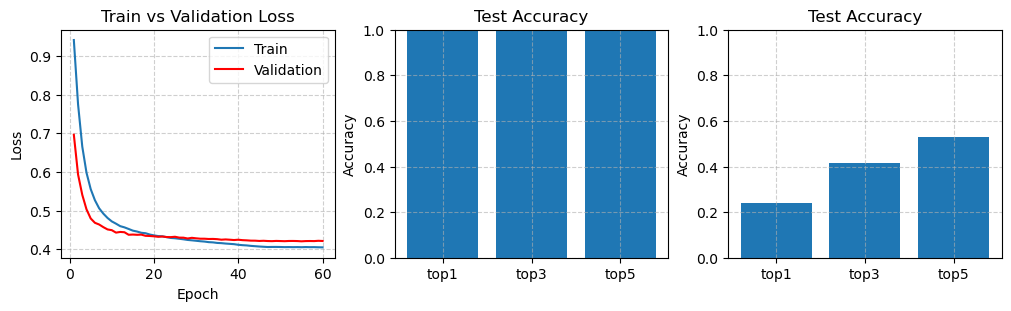

In [15]:
from cowaver.checkpoints import cargar_checkpoint

phonological_route_net = PhonologicalRouteNet()
train_history = cargar_checkpoint(phonological_route_net, folder=checkpoints_path / "visual", silent=True)
training_test_results = evaluar_red(phonological_route_net, training_data)
generalization_test_results = evaluar_red(phonological_route_net, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

In [16]:
import matplotlib.pyplot as plt
from cowaver.datamodules import TinyPairedMel
from cowaver.utils import extraer_waveform, make_image
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_route_net = PhonologicalRouteNet()
cargar_checkpoint(phonological_route_net, folder=checkpoints_path / "visual", silent=True)
phonological_route_net.eval()

@widgets.interact(word="buzo")
def explore_phonological_route(word: str):
    image = make_image(word)
    with torch.no_grad():
        mel, h = phonological_route_net(image)
    mel = mel.squeeze(1).transpose(1, 2)
    waveform = extraer_waveform(mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
        fig.suptitle(word)
        graficar_waveform(waveform, ax=axes[0])
        graficar_mel(mel, ax=axes[1])
        graficar_embedding(h, ax=axes[2], vmin=h.min(), vmax=h.max())
        plt.show()
        
    display(widgets.VBox([out, audio_widget(waveform)]))

interactive(children=(Text(value='buzo', description='word'), Output()), _dom_classes=('widget-interact',))